In [ ]:
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score

In [5]:
df = pd.read_csv(r"C:\Users\cecil\Cript_Anomalies\BTCUSDT_20180101_20260112.csv", delimiter=";", skiprows=0)
display(df)

,open_time,open,high,low,close,volume,close_time,quote_asset_volume,n_trades,taker_buy_base,...,ignore,symbol,interval,log_return,volatility_20,range_hl,trades_per_volume,buy_ratio,z_return,anomaly_simple
0,2018-01-01 00:00:00+00:00,13715.65,13715.65,13400.01,13556.15,123.616013,2018-01-01 00:14:59.999000+00:00,1.675545e+06,1572,63.227133,...,0,BTCUSDT,15m,NaN,NaN,0.023013,12.716799,0.511480,NaN,False
1,2018-01-01 00:15:00+00:00,13533.75,13550.87,13402.00,13521.12,98.136430,2018-01-01 00:29:59.999000+00:00,1.321757e+06,1461,47.686389,...,0,BTCUSDT,15m,-0.002587,NaN,0.011000,14.887438,0.485919,-0.691986,False
2,2018-01-01 00:30:00+00:00,13500.00,13545.37,13450.00,13470.41,79.904037,2018-01-01 00:44:59.999000+00:00,1.078825e+06,1000,43.710406,...,0,BTCUSDT,15m,-0.003757,NaN,0.007064,12.515012,0.547036,-1.004095,False
3,2018-01-01 00:45:00+00:00,13494.65,13690.87,13450.00,13529.01,141.699719,2018-01-01 00:59:59.999000+00:00,1.917783e+06,1195,73.897993,...,0,BTCUSDT,15m,0.004341,NaN,0.017849,8.433327,0.521511,1.156086,False
4,2018-01-01 01:00:00+00:00,13528.99,13571.74,13402.28,13445.63,72.537533,2018-01-01 01:14:59.999000+00:00,9.778198e+05,898,34.257652,...,0,BTCUSDT,15m,-0.006182,NaN,0.012526,12.379798,0.472275,-1.650855,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
281126,2026-01-12 22:30:00+00:00,91269.52,91402.81,91203.69,91339.90,86.681550,2026-01-12 22:44:59.999000+00:00,7.912440e+06,28813,50.482400,...,0,BTCUSDT,15m,0.000771,0.001837,0.002182,332.400609,0.582389,0.203804,False
281127,2026-01-12 22:45:00+00:00,91339.89,91339.90,91214.00,91244.99,60.451790,2026-01-12 22:59:59.999000+00:00,5.517664e+06,19198,18.105290,...,0,BTCUSDT,15m,-0.001040,0.001788,0.001378,317.575377,0.299500,-0.279123,False
281128,2026-01-12 23:00:00+00:00,91244.99,91280.99,91059.88,91160.07,180.361250,2026-01-12 23:14:59.999000+00:00,1.643558e+07,26239,91.014310,...,0,BTCUSDT,15m,-0.000931,0.001721,0.002423,145.480251,0.504622,-0.250178,False
281129,2026-01-12 23:15:00+00:00,91160.07,91282.39,91135.58,91269.34,31.328540,2026-01-12 23:29:59.999000+00:00,2.857620e+06,9456,19.653920,...,0,BTCUSDT,15m,0.001198,0.001643,0.001610,301.833408,0.627349,0.317736,False


In [6]:
def fit_isolation_forest(
    df: pd.DataFrame,
    features,
    contamination: float = 0.01,
    n_estimators: int = 300,
    random_state: int = 42
):
    """
    Ejecuta Isolation Forest y devuelve:
    - df_result con anomaly_if y if_score
    - modelo entrenado
    """

    df_model = df.copy()

    X = (
        df_model[features]
        .replace([np.inf, -np.inf], np.nan)
        .dropna()
    )

    idx = X.index

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    model = IsolationForest(
        n_estimators=n_estimators,
        contamination=contamination,
        random_state=random_state,
        n_jobs=-1
    )

    model.fit(X_scaled)

    pred = model.predict(X_scaled)  # 1 normal, -1 anomalía
    scores = -model.score_samples(X_scaled)  # invertimos para que mayor = más anómalo

    df_model["anomaly_if"] = np.nan
    df_model["if_score"] = np.nan

    df_model.loc[idx, "anomaly_if"] = (pred == -1)
    df_model.loc[idx, "if_score"] = scores

    return df_model, model

In [ ]:
def evaluar_modelo(
    df_result: pd.DataFrame,
    anomaly_col: str = "anomaly_if",
    score_col: str = "if_score",
    zscore_col: str = "anomaly_simple",
    y_true_col: str = None
):
    """
    Calcula métricas estandarizadas para Isolation Forest.

    Métricas:
    - Anomaly Rate
    - Distribución del score
    - Overlap con Z-score, si existe anomaly_simple
    - Precision, Recall, F1 y AUC, si existe variable real y_true_col
    """

    df_eval = df_result.copy()

    # Nos quedamos solo con filas donde el modelo sí predijo
    df_eval = df_eval.dropna(subset=[anomaly_col, score_col])

    y_pred = df_eval[anomaly_col].astype(bool)
    scores = df_eval[score_col].astype(float)

    metricas = {}

    # 1. Total de observaciones evaluadas
    metricas["total_observaciones"] = len(df_eval)

    # 2. Total de anomalías detectadas
    metricas["total_anomalias"] = int(y_pred.sum())

    # 3. Anomaly Rate
    metricas["anomaly_rate"] = y_pred.mean()

    # 4. Distribución del score
    metricas["score_media"] = scores.mean()
    metricas["score_std"] = scores.std()
    metricas["score_min"] = scores.min()
    metricas["score_p50"] = scores.quantile(0.50)
    metricas["score_p95"] = scores.quantile(0.95)
    metricas["score_p99"] = scores.quantile(0.99)
    metricas["score_max"] = scores.max()

    # 5. Overlap con Z-score
    if zscore_col in df_eval.columns:
        z_anom = df_eval[zscore_col].astype(bool)

        anom_modelo = set(df_eval.index[y_pred])
        anom_zscore = set(df_eval.index[z_anom])

        interseccion = anom_modelo.intersection(anom_zscore)

        metricas["zscore_total_anomalias"] = len(anom_zscore)
        metricas["overlap_zscore_n"] = len(interseccion)

        if len(anom_zscore) > 0:
            metricas["overlap_zscore_pct"] = len(interseccion) / len(anom_zscore)
        else:
            metricas["overlap_zscore_pct"] = np.nan

    # 6. Métricas supervisadas si existe etiqueta real
    if y_true_col is not None and y_true_col in df_eval.columns:
        y_true = df_eval[y_true_col].astype(bool)

        metricas["precision"] = precision_score(y_true, y_pred, zero_division=0)
        metricas["recall"] = recall_score(y_true, y_pred, zero_division=0)
        metricas["f1_score"] = f1_score(y_true, y_pred, zero_division=0)

        try:
            metricas["auc"] = roc_auc_score(y_true, scores)
        except ValueError:
            metricas["auc"] = np.nan

    return pd.DataFrame([metricas])

In [9]:
def plot_if_results(df, time_col="open_time", price_col="close"):

    df_plot = df.dropna(subset=["anomaly_if"])

    # Precio + anomalías
    plt.figure()
    plt.plot(df_plot[time_col], df_plot[price_col])
    anomalies = df_plot[df_plot["anomaly_if"] == True]
    plt.scatter(anomalies[time_col], anomalies[price_col])
    plt.title("Precio con anomalías detectadas por Isolation Forest")
    plt.show()

    # Score en el tiempo
    plt.figure()
    plt.plot(df_plot[time_col], df_plot["if_score"])
    plt.title("Isolation Forest Score en el tiempo")
    plt.show()

    # Histograma
    plt.figure()
    plt.hist(df_plot["if_score"].dropna(), bins=50)
    plt.title("Distribución del Isolation Forest Score")
    plt.show()

In [10]:
def plot_if_pca_score(df, features):

    d = df.dropna(subset=features + ["if_score"]).copy()

    X = d[features]
    scores = d["if_score"].values

    X_scaled = StandardScaler().fit_transform(X)

    pca = PCA(n_components=2)
    X2 = pca.fit_transform(X_scaled)

    plt.figure()
    sc = plt.scatter(X2[:, 0], X2[:, 1], c=scores, cmap="RdYlGn_r")
    plt.colorbar(sc, label="Anomaly Score")
    plt.title("Isolation Forest PCA score")
    plt.show()

In [11]:
def plot_normal_vs_anomalous(
    df,
    y_col: str,
    anomaly_col: str,
    title: str = None,
    x_mode: str = "index",   # "index" o "time"
    time_col: str = "open_time",
):
    """
    Scatter de puntos normales vs anómalos como en el ejemplo.
    
    y_col: columna a graficar en Y (ej. 'close', 'volume', 'log_return')
    anomaly_col: columna booleana (True=anomalía) (ej. 'anomaly_if' o 'anomaly_lof')
    x_mode: 'index' o 'time'
    """

    d = df.dropna(subset=[y_col, anomaly_col]).copy()

    # Eje X
    if x_mode == "time" and time_col in d.columns:
        x = d[time_col]
        x_label = time_col
    else:
        x = np.arange(len(d))
        x_label = "Data points"

    normal = d[anomaly_col].astype(bool) == False
    anomal = d[anomaly_col].astype(bool) == True

    plt.figure()
    plt.scatter(x[normal], d.loc[normal, y_col], label="0 (normal)")
    plt.scatter(x[anomal], d.loc[anomal, y_col], label="1 (anomalía)")
    plt.xlabel(x_label)
    plt.ylabel(y_col)
    plt.title(title or f"Normal vs Anómalo: {y_col}")
    plt.legend(title="Predicted Class")
    plt.show()

In [12]:
features = [
    "log_return",
    "volatility_20",
    "range_hl",
    "trades_per_volume",
    "buy_ratio"
]

In [13]:
df_if, model_if = fit_isolation_forest(df, features)

C:\Users\cecil\AppData\Local\Temp\ipykernel_22404\3034634004.py:42: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[False False False ... False False False]' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df_model.loc[idx, "anomaly_if"] = (pred == -1)


In [ ]:
metricas_if = evaluar_modelo(
    df_result=df_if,
    anomaly_col="anomaly_if",
    score_col="if_score",
    zscore_col="anomaly_simple"
)
print(metricas_if)

   total_observaciones  total_anomalias  anomaly_rate  score_media  score_std  \
0               281097             2811          0.01     0.414579   0.063496   

   score_min  score_p50  score_p95  score_p99  score_max  \
0   0.343006   0.392657   0.544088   0.642958   0.782696   

   zscore_total_anomalias  overlap_zscore_n  overlap_zscore_pct  
0                    4819              2315             0.48039  


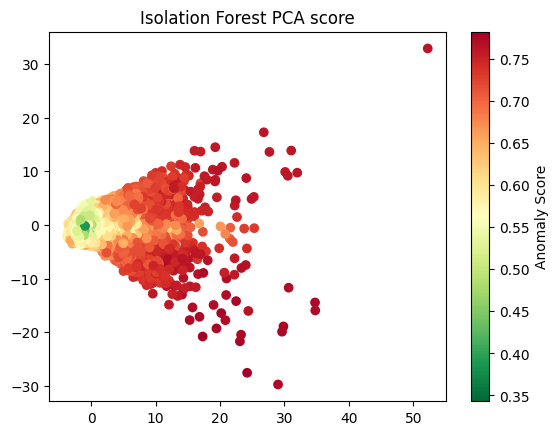

In [13]:
plot_if_pca_score(df_if, features)

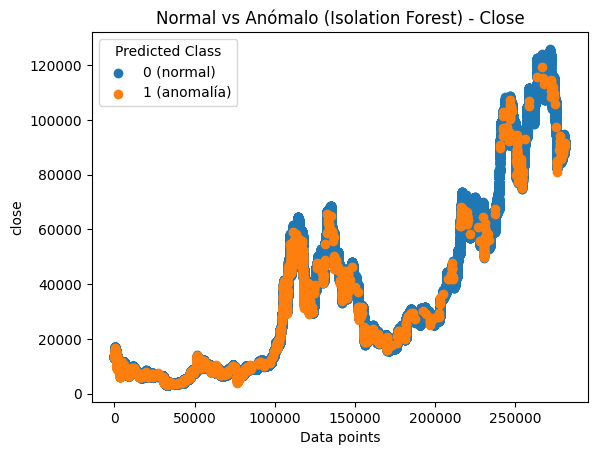

In [14]:
# ejemplo: graficar con close
plot_normal_vs_anomalous(
    df_if,
    y_col="close",
    anomaly_col="anomaly_if",
    title="Normal vs Anómalo (Isolation Forest) - Close",
    x_mode="index"
)

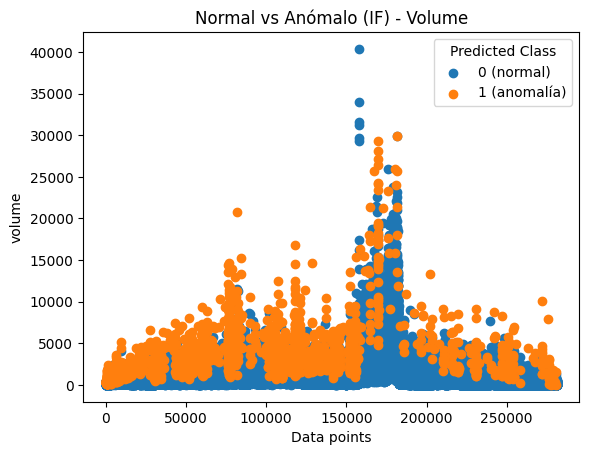

In [15]:
plot_normal_vs_anomalous(df_if, y_col="volume", anomaly_col="anomaly_if",
                         title="Normal vs Anómalo (IF) - Volume")